## Methodology & Background
Accurate estimation of delta channel slope requires isolating the primary hydrodynamic mainstem channel from the river inlet to the shoreline. 

### Methodological Features:
1. **Inlet Column Range Apex Line (`cols=140..162`, `row <= 23`):**
   - Designates the entire inlet width as the hydraulic line of departure ($S=0$).
   - Both eastern and western distributaries start naturally at $S=0$ without artificial detour loops.
2. **Depth-Weighted Dijkstra Pathfinding:**
   - Graph edge cost is weighted inversely with local depth: $\text{Cost} = d_m / \bar{h}^\alpha$ (with $\alpha \ge 1.0$).
   - Guides the search through the deepest thalweg, identifying the hydrodynamic primary branch.
3. **Longitudinal Slope Linear Regression:**
   - Fits bed elevation $\eta(S)$ against along-channel distance $S$:
     $$\eta(S) = m \cdot S + b, \quad S_{ch} = |m| \quad (\text{m/m})$$
4. **Unified Architecture (`MainstemPlanform`):**
   - Seamlessly extracts the mainstem, computes longitudinal slope, provides 2D and 1D visualizations.


In [3]:
# 0. Setup & Import from sandplover.plan
import os
import sys
import warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

# Ensure local repository is in python path
REPO_ROOT = os.path.abspath('..')
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import sandplover as sp
from sandplover.plan import (
    MainstemPlanform,
)
from sandplover.plot import append_colorbar

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = os.path.join(REPO_ROOT, 'sandplover', 'sample_data', 'files')
print("✅ Imports successful!")
print("   MainstemPlanform loaded from:", MainstemPlanform.__module__)
print("   Sample data directory        :", DATA_DIR)


✅ Imports successful!
   MainstemPlanform loaded from: sandplover.plan
   Sample data directory        : /Users/minsik/Desktop/github/Sandplover/sandplover/sample_data/files


## 2. Dataset (Final Timestep $T=300$)

We load the final timestep snapshot for scenario **`S1_No_Flood`** (constant discharge) from `sandplover/sample_data/files/`:


In [4]:
# Load S1 baseline dataset
s1_path = os.path.join(DATA_DIR, 'S1_No_Flood_final_timestep.nc')
ds_s1 = xr.open_dataset(s1_path)

eta_s1 = ds_s1['eta'].values
depth_s1 = ds_s1['water_depth'].values
vel_s1 = ds_s1['velocity'].values
ch_mask_s1 = ds_s1['channel_mask'].values.astype(bool)
land_mask_s1 = ds_s1['land_mask'].values.astype(bool)

print("S1_No_Flood Summary:")
print(f"  Grid dimensions : {eta_s1.shape[0]} rows x {eta_s1.shape[1]} cols")
print(f"  Pixel resolution: {ds_s1.attrs.get('pixel_size_m', 25.0)} meters")
print(f"  Channel pixels  : {ch_mask_s1.sum():,} px ({ch_mask_s1.sum() * 25**2 / 1e6:.2f} km²)")
print(f"  Inlet apex cols : {ds_s1.attrs.get('inlet_apex_cols', '140..162')}")


S1_No_Flood Summary:
  Grid dimensions : 227 rows x 302 cols
  Pixel resolution: 25.0 meters
  Channel pixels  : 2,159 px (1.35 km²)
  Inlet apex cols : 140..162


##  3. Main Channel Selection (`MainstemPlanform.extract`)

We extract the primary thalweg channel using `MainstemPlanform.extract()`:
- Internally generates a 1D centerline network via sandplover's `CenterlineMask`.
- Uses `apex_cols=range(140, 163)` as the hydraulic origin line ($S=0$).
- Applies depth-weighted Dijkstra search to trace the deepest thalweg downstream to the delta shoreline.


In [5]:
# Extract Mainstem Channel
mainstem_s1 = MainstemPlanform.extract(
    channel_mask=ch_mask_s1,
    water_depth=depth_s1,
    land_mask=land_mask_s1,
    pixel_size=25.0,
    apex_y_max=23,
    apex_cols=range(140, 163),
    depth_alpha=1.0,
    name="S1_No_Flood"
)

print(f"✅ MainstemPlanform extracted successfully:")
print(f"   Name              : {mainstem_s1.name}")
print(f"   Total length      : {mainstem_s1.length_km:.3f} km ({mainstem_s1.s_m[-1]:.1f} m)")
print(f"   Coordinates count : {mainstem_s1.n_points} nodes")
print(f"   Inlet source nodes: {len(mainstem_s1.inlet_coords)}")


✅ MainstemPlanform extracted successfully:
   Name              : S1_No_Flood
   Total length      : 2.728 km (2727.8 m)
   Coordinates count : 101 nodes
   Inlet source nodes: 6


### 2D Planform Map Visualization

We display the extracted thalweg over the delta elevation map using `mainstem_s1.show()`:


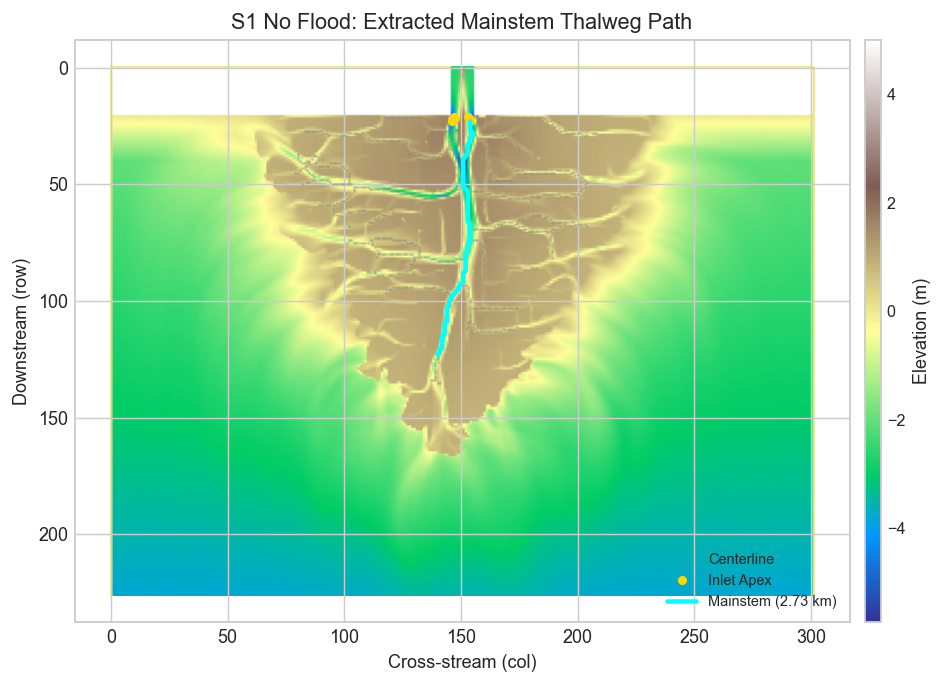

In [6]:
# 2D Planform Visualization
fig, ax = plt.subplots(figsize=(8, 6), dpi=130)
mainstem_s1.show(
    ax=ax,
    background=eta_s1,
    cmap="terrain",
    path_color="cyan",
    path_linewidth=2.5,
    show_skeleton=True,
    show_inlet=True,
    title="S1 No Flood: Extracted Mainstem Thalweg Path"
)
plt.show()


## 4. Longitudinal Slope Estimation (`mainstem.compute_slope`)

Using `mainstem_s1.compute_slope(eta)`, bed elevation $\eta(S)$ is sampled along the thalweg distance $S$ to calculate:
- Bed slope $m$ (m/m) and absolute channel slope $S_{ch} = |m|$
- Linear regression metrics: $R^2$, $p$-value, standard error
- Average thalweg water depth along the path


Channel Slope Results (S1):
  Bed Slope (m_fit)   : +9.707231e-04 m/m
  Absolute Slope (Sch): 0.000971 m/m (0.971 m/km)
  Regression R²       : 0.4895
  Mean Thalweg Depth  : 3.73 m
  Total Distance      : 2.73 km


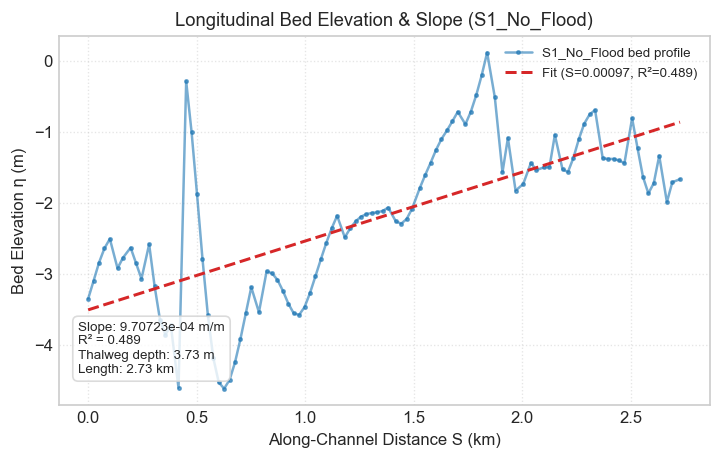

In [7]:
# Compute channel slope on MainstemPlanform instance
slope_stats = mainstem_s1.compute_slope(eta_s1, water_depth=depth_s1)

print("Channel Slope Results (S1):")
print(f"  Bed Slope (m_fit)   : {mainstem_s1.m_fit:+.6e} m/m")
print(f"  Absolute Slope (Sch): {mainstem_s1.abs_slope:.6f} m/m ({mainstem_s1.abs_slope * 1000:.3f} m/km)")
print(f"  Regression R²       : {mainstem_s1.r_squared:.4f}")
print(f"  Mean Thalweg Depth  : {mainstem_s1.thalweg_depth_m:.2f} m")
print(f"  Total Distance      : {mainstem_s1.length_km:.2f} km")

# Plot 1D longitudinal elevation profile and linear regression
ax = mainstem_s1.show_profile(
    color="#1f77b4",
    line_color="#d62728",
    show_stats=True
)
plt.show()
